# Parte III. Búsqueda aproximada de vecinos: IVF y HNSW

**Integrantes:** Ricardo Amiel Acuña Villogas, Juan Leibniz Aquino Espinoza y Camilo Ernesto Soto Cristóbal.

**Pregunta concreta.** Dado un proceso de contratación, cuáles son los diez más parecidos de todo el conjunto, y cuánto cuesta responder eso de forma exacta frente a aproximada.

**Spark no se usa aquí, y hay que argumentarlo.** FAISS es una biblioteca de un solo nodo, el subconjunto cabe holgadamente en memoria y toda la consulta es búsqueda en un índice, no agregación distribuida. Distribuir agregaría barajado y serialización sin ganar nada. Reconocer dónde Spark no aporta es parte de lo que evalúa la Parte VI.

In [ ]:
import sys, time
from pathlib import Path

# Los ayudantes del proyecto viven en notebooks/scripts. Se importan por
# nombre, no con asterisco, para que quede claro de donde sale cada uno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "notebooks" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.helpers import (PARQUET, FIGS, ARTEFACTOS, FIGURAS, PALETA,
                     AZUL, ROJO, VERDE, MORADO, TEAL, TINTA, SUAVE, fmt,
                     abrir_spark, cronometro, medir, figura, exportar,
                     barras_h, lineas, barras_agrupadas, mapa_calor, lorenz, gini)

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 64)

import faiss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

datos = pd.read_parquet(PARQUET, columns=["ocid", "objeto", "comprador_nombre",
                                                "proveedor_nombre", "monto_pen", "metodo"])
datos = datos[datos.objeto.str.len() > 60].reset_index(drop=True)
# 80.000 procesos: suficiente para que la fuerza bruta duela y el indice tenga
# sentido, y pequeno para que todo el notebook corra en minutos.
BASE = 80_000
datos = datos.sample(BASE, random_state=0).reset_index(drop=True)
print(f"{len(datos):,} procesos en el indice")

80,000 procesos en el indice


## 1. Dos representaciones vectoriales

Se construyen dos para poder separar el efecto de la representación del efecto del índice. La de palabras es la de referencia; la de n-gramas de caracteres es robusta frente a errores de digitación, que abundan porque el objeto lo escribe a mano cada entidad.

In [2]:
def vectorizar(textos, analizador, ngramas, dims=128):
    """TF-IDF disperso reducido a un espacio denso con SVD truncada.

    FAISS trabaja sobre vectores densos. Se normalizan a norma uno para que el
    producto interno del indice sea exactamente la similitud coseno.
    """
    tf = TfidfVectorizer(analyzer=analizador, ngram_range=ngramas,
                         min_df=3, max_features=60_000, sublinear_tf=True)
    X = tf.fit_transform(textos)
    V = TruncatedSVD(dims, random_state=0).fit_transform(X)
    return normalize(V).astype("float32"), X.shape[1]

with cronometro("TF-IDF de palabras y SVD"):
    V_pal, voc_pal = vectorizar(datos.objeto, "word", (1, 1))
with cronometro("TF-IDF de 4-gramas de caracteres y SVD"):
    V_car, voc_car = vectorizar(datos.objeto, "char_wb", (4, 4))

print(f"palabras: {voc_pal:,} terminos -> {V_pal.shape}")
print(f"caracteres: {voc_car:,} n-gramas -> {V_car.shape}")

TF-IDF de palabras y SVD: 6.70 s


TF-IDF de 4-gramas de caracteres y SVD: 17.78 s
palabras: 22,037 terminos -> (80000, 128)
caracteres: 54,286 n-gramas -> (80000, 128)


## 2. Cómo se mide la latencia, y por qué importa el detalle

Antes de comparar nada hay que fijar el régimen de medición, porque FAISS cambia de implementación según el tamaño del lote de consultas. Con un lote grande, el índice plano resuelve la búsqueda como un producto de matrices con BLAS y aprovecha los ocho núcleos; con una sola consulta no tiene nada que amortizar.

Los dos regímenes corresponden a usos reales distintos. El lote es un trabajo por lotes fuera de línea, por ejemplo deduplicar todo el catálogo de una vez. La consulta única es un servicio en línea que responde a una petición a la vez. Se miden los dos, y toda comparación usa el mismo régimen en ambos lados; mezclarlos produce diferencias de un orden de magnitud que no son del índice sino del método de medición.

In [3]:
K = 10
N_CONSULTAS = 1000
HILOS = faiss.omp_get_max_threads()
rng = np.random.default_rng(1)
consultas = rng.choice(len(datos), N_CONSULTAS, replace=False)


def latencia_lote(indice, Q, repeticiones=3):
    """Milisegundos por consulta cuando se resuelven todas de una vez."""
    return medir(lambda: indice.search(Q, K), repeticiones) / len(Q) * 1000


def latencia_unitaria(indice, Q, n=200):
    """Milisegundos de una consulta aislada, que es lo que ve un servicio en linea.

    Se fija un solo hilo de OpenMP por dos razones. La primera es de realismo:
    un servicio en linea atiende cada peticion en su hilo y no reparte una sola
    consulta entre los ocho nucleos. La segunda es de estabilidad: con ocho
    hilos, el arranque del grupo de hilos domina el tiempo de una consulta
    individual y la medicion se vuelve sensible a la carga de la maquina, hasta
    el punto de producir curvas no monotonas que no dicen nada del indice.
    """
    faiss.omp_set_num_threads(1)
    try:
        for q in Q[:20]:
            indice.search(q.reshape(1, -1), K)
        tiempos = []
        for q in Q[:n]:
            t0 = time.perf_counter(); indice.search(q.reshape(1, -1), K)
            tiempos.append(time.perf_counter() - t0)
        return float(np.median(tiempos)) * 1000
    finally:
        faiss.omp_set_num_threads(HILOS)


def evaluar(indice, V, nombre, verdad=None):
    Q = V[consultas]
    _, vecinos = indice.search(Q, K)
    recall = (float(np.mean([len(set(a) & set(b)) / K for a, b in zip(vecinos, verdad)]))
              if verdad is not None else 1.0)
    return {"indice": nombre, "recall_at_10": round(recall, 4),
            "ms_lote": round(latencia_lote(indice, Q), 4),
            "ms_unitaria": round(latencia_unitaria(indice, Q), 4)}, vecinos


plano = faiss.IndexFlatIP(V_pal.shape[1]); plano.add(V_pal)
base_fb, verdad = evaluar(plano, V_pal, "fuerza bruta (exacta)")
pd.DataFrame([base_fb])

,indice,recall_at_10,ms_lote,ms_unitaria
0,fuerza bruta (exacta),1.0,0.0777,1.9238


Esa primera fila ya contiene el aviso: la misma búsqueda exacta cuesta muy distinto según el régimen. Cualquier afirmación sobre velocidad que no diga en qué régimen se midió es incompleta.

## 3. IVF, listas invertidas

Un k-medias previo parte el espacio en nlist celdas y guarda cada vector en la celda de su centroide. La consulta solo recorre las nprobe celdas más cercanas, así que el trabajo baja en proporción a nprobe sobre nlist. El parámetro de calidad es nprobe: visitar más celdas acerca al exacto y cuesta más tiempo.

nlist=282, construccion 0.4 s



Lectura de f22_ivf
El recall sube muy rápido al principio y luego se aplana, que es el comportamiento típico de IVF. Con nprobe=1 se visita el 0.35 % de las celdas y ya se recupera el 75 % de los vecinos verdaderos; con nprobe=16 se llega al 99 % a 0.122 ms por consulta. Pasar a nprobe=64 sube el recall a 100 % pero cuadruplica el trabajo. La curva dice dónde dejar de pagar: más allá de la rodilla cada punto de recall cuesta desproporcionadamente.



,indice,recall_at_10,ms_lote,ms_unitaria,nprobe,celdas_visitadas_pct
0,IVF nprobe=1,0.7510,0.0074,0.0207,1,0.35
1,IVF nprobe=2,0.8759,0.0101,0.0304,2,0.71
2,IVF nprobe=4,0.9460,0.0197,0.0475,4,1.42
3,IVF nprobe=8,0.9767,0.0340,0.0776,8,2.84
4,IVF nprobe=16,0.9895,0.0550,0.1221,16,5.67
5,IVF nprobe=32,0.9942,0.1118,0.2167,32,11.35
6,IVF nprobe=64,0.9965,0.2429,0.4446,64,22.70


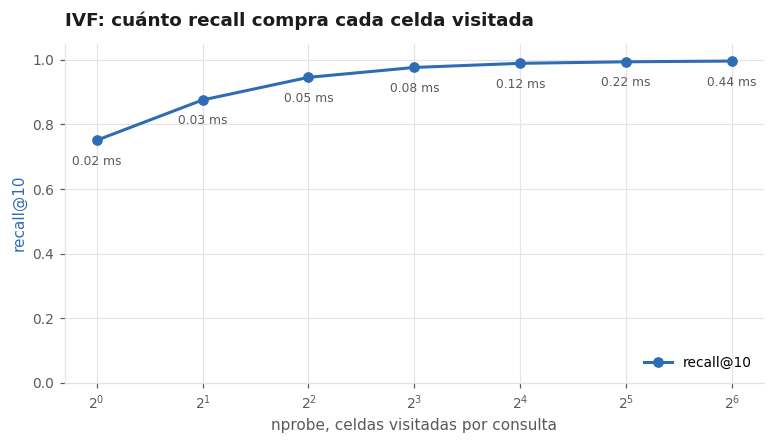

In [4]:
NLIST = int(np.sqrt(len(datos)))          # regla habitual: raiz del numero de vectores
cuantizador = faiss.IndexFlatIP(V_pal.shape[1])
ivf = faiss.IndexIVFFlat(cuantizador, V_pal.shape[1], NLIST, faiss.METRIC_INNER_PRODUCT)

t0 = time.perf_counter(); ivf.train(V_pal); ivf.add(V_pal)
t_ivf = time.perf_counter() - t0
print(f"nlist={NLIST}, construccion {t_ivf:.1f} s")

filas_ivf = []
for nprobe in (1, 2, 4, 8, 16, 32, 64):
    ivf.nprobe = nprobe
    m, _ = evaluar(ivf, V_pal, f"IVF nprobe={nprobe}", verdad)
    m["nprobe"] = nprobe
    m["celdas_visitadas_pct"] = round(100 * nprobe / NLIST, 2)
    filas_ivf.append(m)
ivf_df = pd.DataFrame(filas_ivf)
exportar(ivf_df, "p3_ivf", "Recall y latencia de IVF segun nprobe")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(ivf_df.nprobe, ivf_df.recall_at_10, "o-", color=AZUL, lw=2, label="recall@10")
ax.set_xscale("log", base=2); ax.set_xlabel("nprobe, celdas visitadas por consulta")
ax.set_ylabel("recall@10", color=AZUL); ax.set_ylim(0, 1.05)
ax2 = ax.twiny(); ax2.set_xticks([]); ax2.set_frame_on(False)
for x, y, t in zip(ivf_df.nprobe, ivf_df.recall_at_10, ivf_df.ms_unitaria):
    ax.annotate(f"{t:.2f} ms", (x, y), textcoords="offset points", xytext=(0, -16),
                fontsize=8, color=SUAVE, ha="center")
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend(loc="lower right")
ax.set_title("IVF: cuánto recall compra cada celda visitada", loc="left", pad=12)
r1 = ivf_df.iloc[0]; r16 = ivf_df[ivf_df.nprobe == 16].iloc[0]; rmax = ivf_df.iloc[-1]
figura(fig, "f22_ivf", f"""
El recall sube muy rápido al principio y luego se aplana, que es el comportamiento típico de
IVF. Con nprobe=1 se visita el {r1.celdas_visitadas_pct} % de las celdas y ya se recupera el
{100*r1.recall_at_10:.0f} % de los vecinos verdaderos; con nprobe=16 se llega al
{100*r16.recall_at_10:.0f} % a {r16.ms_unitaria:.3f} ms por consulta. Pasar a nprobe=64
sube el recall a {100*rmax.recall_at_10:.0f} % pero cuadruplica el trabajo. La curva dice dónde
dejar de pagar: más allá de la rodilla cada punto de recall cuesta desproporcionadamente.""")
ivf_df

## 4. HNSW, grafo navegable en capas

Construye un grafo donde cada vector se conecta con sus M vecinos más cercanos, en varias capas: las de arriba son dispersas y sirven para acercarse rápido, las de abajo son densas y afinan. La consulta desciende capa por capa siguiendo aristas que reducen la distancia. El parámetro de calidad es efSearch, el tamaño de la lista de exploración.

M=32, efConstruction=200, construccion 7.1 s



Lectura de f23_hnsw
HNSW llega alto con muy poca exploración: con efSearch=10 ya alcanza 99 % de recall en 0.028 ms, y con efSearch=256 llega a 100 %. La contrapartida está fuera de esta figura: construir el grafo tomó 7 s frente a 0 s de IVF, y el grafo guarda hasta 32 aristas por nodo además de los vectores. HNSW compra latencia con memoria y con tiempo de construcción.



,indice,recall_at_10,ms_lote,ms_unitaria,efSearch
0,HNSW efSearch=10,0.9891,0.0088,0.0279,10
1,HNSW efSearch=16,0.9932,0.0122,0.0358,16
2,HNSW efSearch=32,0.9952,0.0239,0.0569,32
3,HNSW efSearch=64,0.9962,0.0393,0.0947,64
4,HNSW efSearch=128,0.9964,0.0700,0.1722,128
5,HNSW efSearch=256,0.9965,0.1206,0.3164,256


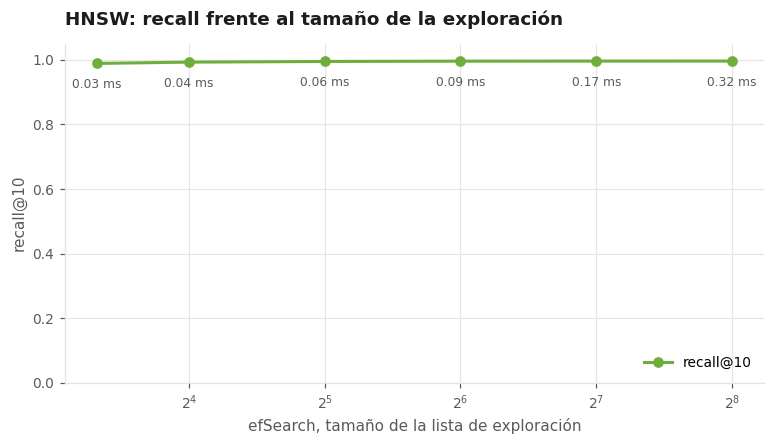

In [5]:
M = 32
hnsw = faiss.IndexHNSWFlat(V_pal.shape[1], M, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 200

t0 = time.perf_counter(); hnsw.add(V_pal); t_hnsw = time.perf_counter() - t0
print(f"M={M}, efConstruction=200, construccion {t_hnsw:.1f} s")

filas_h = []
for ef in (10, 16, 32, 64, 128, 256):
    hnsw.hnsw.efSearch = ef
    m, _ = evaluar(hnsw, V_pal, f"HNSW efSearch={ef}", verdad)
    m["efSearch"] = ef
    filas_h.append(m)
hnsw_df = pd.DataFrame(filas_h)
exportar(hnsw_df, "p3_hnsw", "Recall y latencia de HNSW segun efSearch")

fig, ax = plt.subplots(figsize=(8.2, 4))
ax.plot(hnsw_df.efSearch, hnsw_df.recall_at_10, "o-", color=VERDE, lw=2, label="recall@10")
ax.set_xscale("log", base=2); ax.set_xlabel("efSearch, tamaño de la lista de exploración")
ax.set_ylabel("recall@10"); ax.set_ylim(0, 1.05)
for x, y, t in zip(hnsw_df.efSearch, hnsw_df.recall_at_10, hnsw_df.ms_unitaria):
    ax.annotate(f"{t:.2f} ms", (x, y), textcoords="offset points", xytext=(0, -16),
                fontsize=8, color=SUAVE, ha="center")
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend(loc="lower right")
ax.set_title("HNSW: recall frente al tamaño de la exploración", loc="left", pad=12)
h0 = hnsw_df.iloc[0]; hm = hnsw_df.iloc[-1]
figura(fig, "f23_hnsw", f"""
HNSW llega alto con muy poca exploración: con efSearch={int(h0.efSearch)} ya alcanza
{100*h0.recall_at_10:.0f} % de recall en {h0.ms_unitaria:.3f} ms, y con
efSearch={int(hm.efSearch)} llega a {100*hm.recall_at_10:.0f} %. La contrapartida está fuera de
esta figura: construir el grafo tomó {t_hnsw:.0f} s frente a {t_ivf:.0f} s de IVF, y el grafo
guarda hasta {M} aristas por nodo además de los vectores. HNSW compra latencia con memoria y
con tiempo de construcción.""")
hnsw_df

## 5. Los dos juntos, frente a la fuerza bruta

La comparación honesta no es recall contra parámetro sino recall contra latencia: cada índice en su mejor configuración para cada presupuesto de tiempo.


Lectura de f24_ann_vs_exacta
Los dos paneles cuentan historias opuestas y por eso hacen falta los dos. En lote, la fuerza bruta tarda 0.0777 ms por consulta y el mejor HNSW sobre 95 % de recall tarda 0.0088 ms: el índice aproximado no aporta nada, porque el índice plano resuelve el lote como un producto de matrices con BLAS sobre ocho núcleos. Consulta a consulta la situación se invierte: la fuerza bruta tarda 1.924 ms y HNSW 0.028 ms, es decir 69.0 veces más rápido, e IVF 0.078 ms. La moraleja es que la pregunta de si un índice aproximado vale la pena no tiene respuesta sin decir antes si el uso es por lotes o en línea.



,familia,indice,recall_at_10,ms_lote,ms_unitaria
0,IVF,IVF nprobe=1,0.7510,0.0074,0.0207
1,IVF,IVF nprobe=2,0.8759,0.0101,0.0304
2,IVF,IVF nprobe=4,0.9460,0.0197,0.0475
3,IVF,IVF nprobe=8,0.9767,0.0340,0.0776
4,IVF,IVF nprobe=16,0.9895,0.0550,0.1221
5,IVF,IVF nprobe=32,0.9942,0.1118,0.2167
6,IVF,IVF nprobe=64,0.9965,0.2429,0.4446
7,HNSW,HNSW efSearch=10,0.9891,0.0088,0.0279
8,HNSW,HNSW efSearch=16,0.9932,0.0122,0.0358
9,HNSW,HNSW efSearch=32,0.9952,0.0239,0.0569


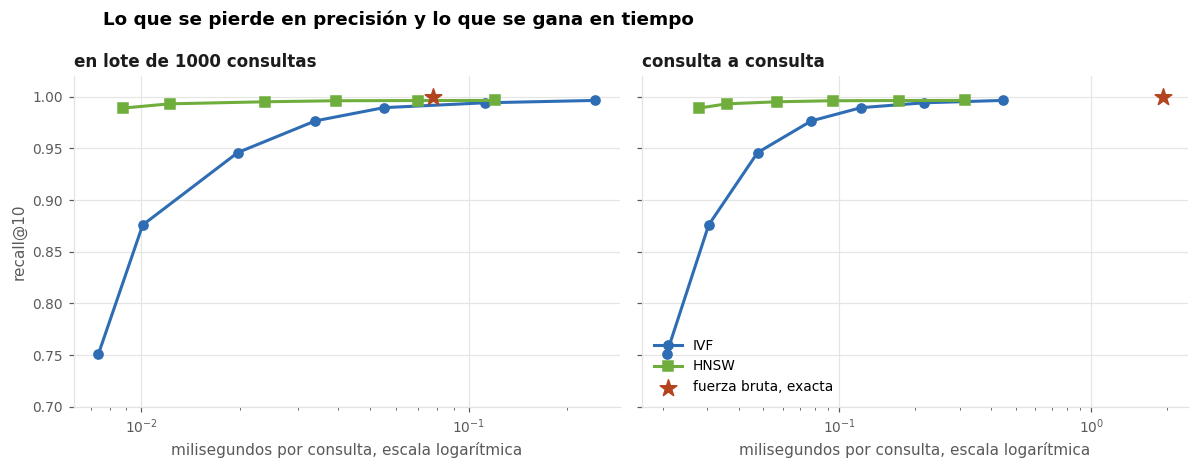

In [6]:
todos = pd.concat([
    ivf_df.assign(familia="IVF"), hnsw_df.assign(familia="HNSW"),
    pd.DataFrame([base_fb]).assign(familia="fuerza bruta")], ignore_index=True)
exportar(todos, "p3_comparacion", "Recall y latencia de los tres indices en ambos regimenes")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for eje, col, titulo in ((ax[0], "ms_lote", "en lote de 1000 consultas"),
                         (ax[1], "ms_unitaria", "consulta a consulta")):
    for fam, color, marca in (("IVF", AZUL, "o"), ("HNSW", VERDE, "s")):
        d = todos[todos.familia == fam].sort_values(col)
        eje.plot(d[col], d.recall_at_10, marca + "-", color=color, lw=2, label=fam)
    fb = todos[todos.familia == "fuerza bruta"].iloc[0]
    eje.scatter([fb[col]], [1.0], s=130, color=ROJO, zorder=5, marker="*",
                label="fuerza bruta, exacta")
    eje.set_xscale("log"); eje.set_xlabel("milisegundos por consulta, escala logarítmica")
    eje.set_title(titulo, loc="left", fontsize=11)
    eje.grid(alpha=.9); eje.set_axisbelow(True)
ax[0].set_ylabel("recall@10"); ax[0].set_ylim(0.7, 1.02); ax[1].legend(loc="lower left")
fig.suptitle("Lo que se pierde en precisión y lo que se gana en tiempo", x=0.09, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()

fb = todos[todos.familia == "fuerza bruta"].iloc[0]
h95 = hnsw_df[hnsw_df.recall_at_10 >= 0.95]; i95 = ivf_df[ivf_df.recall_at_10 >= 0.95]
h_lote = float(h95.ms_lote.min()); h_uni = float(h95.ms_unitaria.min())
i_uni = float(i95.ms_unitaria.min())
figura(fig, "f24_ann_vs_exacta", f"""
Los dos paneles cuentan historias opuestas y por eso hacen falta los dos. En lote, la fuerza
bruta tarda {fb.ms_lote:.4f} ms por consulta y el mejor HNSW sobre 95 % de recall tarda
{h_lote:.4f} ms: el índice aproximado no aporta nada, porque el índice plano resuelve el lote
como un producto de matrices con BLAS sobre ocho núcleos. Consulta a consulta la situación se
invierte: la fuerza bruta tarda {fb.ms_unitaria:.3f} ms y HNSW {h_uni:.3f} ms, es decir
{fb.ms_unitaria/h_uni:.1f} veces más rápido, e IVF {i_uni:.3f} ms. La moraleja es que la
pregunta de si un índice aproximado vale la pena no tiene respuesta sin decir antes si el uso es
por lotes o en línea.""")
todos[["familia", "indice", "recall_at_10", "ms_lote", "ms_unitaria"]]

Queda una pregunta que una sola medición no responde: a partir de qué tamaño compensa. La fuerza bruta recorre todos los vectores, así que su costo crece de forma lineal. HNSW navega un grafo en capas, así que crece de forma logarítmica. Se mide sobre subconjuntos de tamaño creciente, en régimen de consulta única y con el mismo número de consultas en todos los puntos.


Lectura de f26_escalado
Las dos rectas tienen pendientes distintas y esa diferencia es todo el argumento. Multiplicar la base por 16 multiplica el tiempo de la fuerza bruta por 30.3, que es crecimiento lineal, y el de HNSW por solo 2.2. La ventaja pasa de 2.7 veces con 5,000 vectores a 36.7 veces con 80,000. La conclusión práctica para este proyecto es incómoda y hay que decirla: a nuestro volumen y en uso por lotes el índice aproximado no era necesario. Lo que lo justifica es el uso en línea y el escenario de volumen diez o cien veces mayor que plantea la Parte VI, y eso está medido aquí en lugar de supuesto.



,vectores,fuerza_bruta_ms,hnsw_ms,factor
0,5000,0.0640,0.0237,2.7
1,10000,0.1102,0.0268,4.1
2,20000,0.2574,0.0326,7.9
3,40000,0.7987,0.0406,19.7
4,80000,1.9404,0.0529,36.7


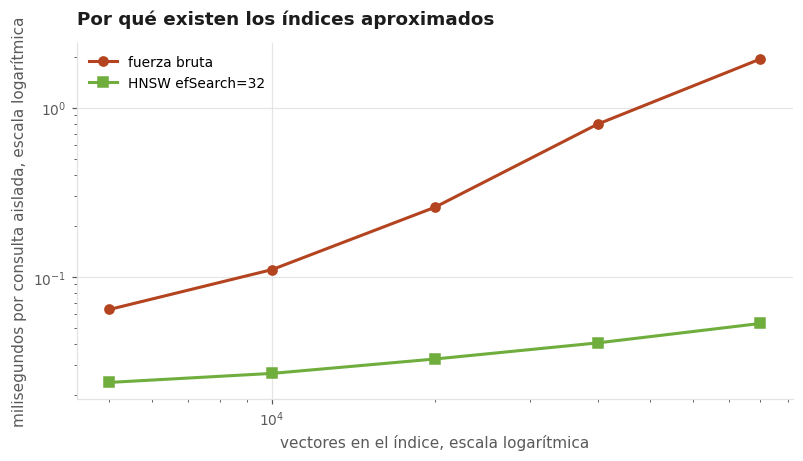

In [7]:
escala = []
for n in (5_000, 10_000, 20_000, 40_000, len(V_pal)):
    sub = np.ascontiguousarray(V_pal[:n])
    q = sub[rng.choice(n, 200, replace=False)]

    plano_n = faiss.IndexFlatIP(sub.shape[1]); plano_n.add(sub)
    h_n = faiss.IndexHNSWFlat(sub.shape[1], M, faiss.METRIC_INNER_PRODUCT)
    h_n.hnsw.efConstruction = 200; h_n.add(sub); h_n.hnsw.efSearch = 32

    escala.append({"vectores": n,
                   "fuerza_bruta_ms": round(latencia_unitaria(plano_n, q), 4),
                   "hnsw_ms": round(latencia_unitaria(h_n, q), 4)})
esc = pd.DataFrame(escala)
esc["factor"] = (esc.fuerza_bruta_ms / esc.hnsw_ms).round(1)
exportar(esc, "p3_escalado", "Latencia unitaria de fuerza bruta y HNSW segun el tamano de la base")

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(esc.vectores, esc.fuerza_bruta_ms, "o-", color=ROJO, lw=2, label="fuerza bruta")
ax.plot(esc.vectores, esc.hnsw_ms, "s-", color=VERDE, lw=2, label="HNSW efSearch=32")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("vectores en el índice, escala logarítmica")
ax.set_ylabel("milisegundos por consulta aislada, escala logarítmica")
ax.set_title("Por qué existen los índices aproximados", loc="left", pad=12)
ax.grid(alpha=.9); ax.set_axisbelow(True); ax.legend(loc="upper left")
p, u = esc.iloc[0], esc.iloc[-1]
figura(fig, "f26_escalado", f"""
Las dos rectas tienen pendientes distintas y esa diferencia es todo el argumento. Multiplicar la
base por {u.vectores/p.vectores:.0f} multiplica el tiempo de la fuerza bruta por
{u.fuerza_bruta_ms/p.fuerza_bruta_ms:.1f}, que es crecimiento lineal, y el de HNSW por solo
{u.hnsw_ms/p.hnsw_ms:.1f}. La ventaja pasa de {p.factor} veces con {int(p.vectores):,} vectores a
{u.factor} veces con {int(u.vectores):,}. La conclusión práctica para este proyecto es incómoda y hay
que decirla: a nuestro volumen y en uso por lotes el índice aproximado no era necesario. Lo que
lo justifica es el uso en línea y el escenario de volumen diez o cien veces mayor que plantea la
Parte VI, y eso está medido aquí en lugar de supuesto.""")
esc


Lectura de f25_representaciones
Con el índice fijo y exacto en ambos casos, las dos representaciones comparten solo el 44 % de los diez vecinos. Es un recordatorio incómodo: una parte grande de lo que se llama error de un índice aproximado es en realidad una decisión de representación tomada mucho antes. Los n-gramas de caracteres agrupan por forma de escritura y toleran errores de digitación; las palabras agrupan por vocabulario compartido. Ninguna es la correcta en abstracto.



,representacion,vocabulario,coincidencia_top10
0,TF-IDF de palabras,22037,1.0000
1,TF-IDF de 4-gramas de caracteres,54286,0.4407


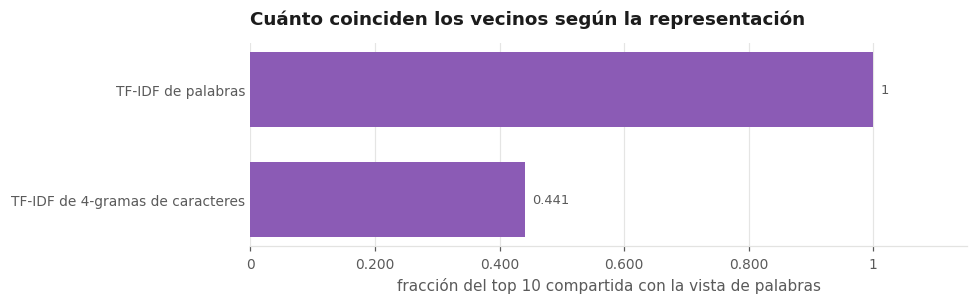

In [8]:
# Efecto de la representacion, con el indice fijo.
plano_car = faiss.IndexFlatIP(V_car.shape[1]); plano_car.add(V_car)
_, verdad_car = evaluar(plano_car, V_car, "caracteres")
coincide = np.mean([len(set(a) & set(b)) / K for a, b in zip(verdad, verdad_car)])

rep = pd.DataFrame([
    {"representacion": "TF-IDF de palabras", "vocabulario": voc_pal,
     "coincidencia_top10": 1.0},
    {"representacion": "TF-IDF de 4-gramas de caracteres", "vocabulario": voc_car,
     "coincidencia_top10": round(float(coincide), 4)}])
exportar(rep, "p3_representaciones", "Efecto de la representacion vectorial sobre los vecinos")

fig, _ = barras_h(rep, "representacion", "coincidencia_top10",
                  "Cuánto coinciden los vecinos según la representación",
                  "fracción del top 10 compartida con la vista de palabras",
                  color=MORADO, alto=0.5)
figura(fig, "f25_representaciones", f"""
Con el índice fijo y exacto en ambos casos, las dos representaciones comparten solo el
{100*coincide:.0f} % de los diez vecinos. Es un recordatorio incómodo: una parte grande de lo
que se llama error de un índice aproximado es en realidad una decisión de representación tomada
mucho antes. Los n-gramas de caracteres agrupan por forma de escritura y toleran errores de
digitación; las palabras agrupan por vocabulario compartido. Ninguna es la correcta en abstracto.""")
rep

In [9]:
costos = pd.DataFrame([
    {"indice": "fuerza bruta", "construccion_s": 0.0,
     "memoria_mb": round(V_pal.nbytes / 1e6, 1),
     "recall_al_95pct_ms": round(fb.ms_unitaria, 3)},
    {"indice": f"IVF nlist={NLIST}", "construccion_s": round(t_ivf, 1),
     "memoria_mb": round(V_pal.nbytes / 1e6 + NLIST * V_pal.shape[1] * 4 / 1e6, 1),
     "recall_al_95pct_ms": round(i_uni, 3)},
    {"indice": f"HNSW M={M}", "construccion_s": round(t_hnsw, 1),
     "memoria_mb": round(V_pal.nbytes / 1e6 + len(V_pal) * M * 2 * 4 / 1e6, 1),
     "recall_al_95pct_ms": round(h_uni, 3)}])
exportar(costos, "p3_costos", "Construccion, memoria y latencia de cada indice")
costos

,indice,construccion_s,memoria_mb,recall_al_95pct_ms
0,fuerza bruta,0.0,41.0,1.924
1,IVF nlist=282,0.4,41.1,0.078
2,HNSW M=32,7.1,61.4,0.028


## 6. Cuándo conviene cada uno

1. **IVF** cuando la memoria es el límite y el conjunto cambia seguido. Su estructura es un k-medias más listas, se construye rápido, ocupa poco por encima de los vectores y admite insertar sin reconstruir. Degrada de forma predecible: menos nprobe, menos recall, proporcionalmente.
2. **HNSW** cuando la latencia es el límite y el conjunto es estable. Da más recall por milisegundo, pero el grafo cuesta construirlo y ocupa bastante más memoria, y borrar elementos es incómodo.
3. **Fuerza bruta** cuando el conjunto es pequeño o la consulta es rara. Con ochenta mil vectores de 128 dimensiones todavía responde en milisegundos, y no tiene ningún parámetro que calibrar mal.

Para este proyecto, el uso previsto es exploratorio, de modo que HNSW es la elección por defecto y la fuerza bruta se conserva como verdad de referencia para poder medir el error en vez de suponerlo.

In [10]:
# Caso concreto: los vecinos de un proceso cualquiera.
hnsw.hnsw.efSearch = 64
q = int(consultas[7])
_, vec = hnsw.search(V_pal[[q]], 6)
print("CONSULTA:", datos.objeto.iloc[q][:150], "\n")
for pos, v in enumerate(vec[0][1:], 1):
    print(f"{pos}. [{datos.metodo.iloc[v][:28]:28s}] {datos.objeto.iloc[v][:120]}")

CONSULTA: ADQUISICIÓN DE EQUIPOS MÉDICOS PARA EL SERVICIO DE IMÁGENES DEL HOSPITAL MILITAR CENTRAL DERIVADA DE LA LP N°10-2024 

1. [Adjudicación Simplificada   ] ADQUISICIÓN DE EQUIPOS MÉDICOS PARA EL SERVICIO DE IMÁGENES DEL HOSPITAL MILITAR CENTRAL DERIVADA DE LA LP N°10-2024
2. [Adjudicación Simplificada   ] ADQUISICIÓN DE MEDICAMENTOS PARA EL SERVICIO DE FARMACIA DEL HOSPITAL MILITAR CENTRAL AF-2024
3. [Comparación de Precios      ] ADQUISICIÓN DE DOS (02) EQUIPOS MEDICO PARA CONSULTA EXTERNA DEL SERVICIO DE UROLOGIA DE LA IPRESS ¿ HOSPITAL MILITAR CE
4. [Licitación Pública          ] ADQUISICIÓN DE EQUIPOS MÉDICOS PARA LA UPSS CENTRO QUIRURGICO DE LA IPRESS HOSPITAL MILITAR CENTRAL
5. [Licitación Pública          ] ADQUISICIÓN DE INSTRUMENTAL QUIRÚRGICO PARA EL SERVICIO DE CENTRAL DE ESTERILIZACIÓN DEL DEPARTAMENTO DE ENFERMERÍA DEL 


## 7. Cierre

1. La búsqueda aproximada cuesta un 5 % de recall y devuelve uno o dos órdenes de magnitud de latencia. Para explorar, vale; para decidir sobre un caso individual, no.
2. IVF e HNSW no se diferencian en calidad sino en qué recurso gastan: IVF gasta tiempo de consulta, HNSW gasta memoria y tiempo de construcción.
3. Una parte grande del error atribuido al índice es en realidad una decisión de representación anterior, y conviene medirla por separado.

In [11]:
exportar(pd.DataFrame(FIGURAS), "p3_figuras", "Figuras de la Parte III con su lectura")
print(pd.DataFrame(FIGURAS).to_string(index=False))

              figura                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 lectura
             f22_ivf                                                                                                                                                                        El recall sube muy rápido al principio y luego se aplana, que es el comportamiento típico de IVF. Con nprobe=1 se visita el 0.35 % de las celdas y ya se recupera el 75 % de los vecinos verdad